# Consensus Conflict Inspection

This notebook visualizes the exact conflict reported by the consensus renderer
and overlays the two conflicting tracks on the raw frame.

Defaults are set to the error you shared:
- Frame: 80
- EmbedSeg track id: 227
- StarDist track id: 123

Adjust the parameters in the next cell if needed.

In [6]:
from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

# --- Parameters ---
# The error message shows *source track ids* and *final track ids*.
# Use source track ids for overlap checks in the source masks.
FRAME_INDEX = 80  # from error message
EMBEDSEG_SOURCE_TRACK_ID = 907
STARDIST_SOURCE_TRACK_ID = 620

# Optional: final track ids reported in the error (not used for source masks).
EMBEDSEG_FINAL_TRACK_ID = 227
STARDIST_FINAL_TRACK_ID = 123

DATASET_ROOT = Path("/group/jug/Sheida/PyTr2d/data/Fluo-N2DL-HeLa_train/Fluo-N2DL-HeLa")
TRACK_SEQUENCE = "02"

EMBEDSEG_DIR = Path("/group/jug/Sheida/PyTr2d/outputs/Fluo-N2DL-HeLa/02/embedseg")
STARDIST_DIR = Path("/group/jug/Sheida/PyTr2d/outputs/Fluo-N2DL-HeLa/02/stardist")

RAW_FRAME_PATH = DATASET_ROOT / TRACK_SEQUENCE / f"t{FRAME_INDEX:03d}.tif"
EMBEDSEG_MASK_PATH = EMBEDSEG_DIR / f"mask{FRAME_INDEX:03d}.tif"
STARDIST_MASK_PATH = STARDIST_DIR / f"mask{FRAME_INDEX:03d}.tif"

print("Raw:", RAW_FRAME_PATH)
print("EmbedSeg mask:", EMBEDSEG_MASK_PATH)
print("StarDist mask:", STARDIST_MASK_PATH)

Raw: /group/jug/Sheida/PyTr2d/data/Fluo-N2DL-HeLa_train/Fluo-N2DL-HeLa/02/t080.tif
EmbedSeg mask: /group/jug/Sheida/PyTr2d/outputs/Fluo-N2DL-HeLa/02/embedseg/mask080.tif
StarDist mask: /group/jug/Sheida/PyTr2d/outputs/Fluo-N2DL-HeLa/02/stardist/mask080.tif


In [7]:
# --- Resolve a valid frame where both tracks exist ---
def _load_lineage(path: Path) -> dict[int, tuple[int, int, int]]:
    rows = {}
    if not path.exists():
        return rows
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) < 4:
            continue
        track_id, begin, end, parent = (int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3]))
        rows[track_id] = (begin, end, parent)
    return rows

embedseg_lineage = _load_lineage(EMBEDSEG_DIR / "res_track.txt")
stardist_lineage = _load_lineage(STARDIST_DIR / "res_track.txt")

embedseg_range = embedseg_lineage.get(EMBEDSEG_SOURCE_TRACK_ID)
stardist_range = stardist_lineage.get(STARDIST_SOURCE_TRACK_ID)

print("EmbedSeg source track range:", embedseg_range)
print("StarDist source track range:", stardist_range)

if embedseg_range and stardist_range:
    common_start = max(embedseg_range[0], stardist_range[0])
    common_end = min(embedseg_range[1], stardist_range[1])
    if common_start <= common_end:
        if not (common_start <= FRAME_INDEX <= common_end):
            FRAME_INDEX = common_start
            print("Adjusted FRAME_INDEX to", FRAME_INDEX, "based on overlap of lifespans.")
    else:
        print("Warning: track lifespans do not overlap. No common frame exists.")
else:
    print("Warning: could not find one or both tracks in lineage files.")

RAW_FRAME_PATH = DATASET_ROOT / TRACK_SEQUENCE / f"t{FRAME_INDEX:03d}.tif"
EMBEDSEG_MASK_PATH = EMBEDSEG_DIR / f"mask{FRAME_INDEX:03d}.tif"
STARDIST_MASK_PATH = STARDIST_DIR / f"mask{FRAME_INDEX:03d}.tif"

print("Resolved frame:", FRAME_INDEX)
print("Raw:", RAW_FRAME_PATH)
print("EmbedSeg mask:", EMBEDSEG_MASK_PATH)
print("StarDist mask:", STARDIST_MASK_PATH)

EmbedSeg source track range: (39, 91, 824)
StarDist source track range: (39, 81, 496)
Resolved frame: 80
Raw: /group/jug/Sheida/PyTr2d/data/Fluo-N2DL-HeLa_train/Fluo-N2DL-HeLa/02/t080.tif
EmbedSeg mask: /group/jug/Sheida/PyTr2d/outputs/Fluo-N2DL-HeLa/02/embedseg/mask080.tif
StarDist mask: /group/jug/Sheida/PyTr2d/outputs/Fluo-N2DL-HeLa/02/stardist/mask080.tif


In [8]:
# --- Load frame and masks ---
raw = tiff.imread(RAW_FRAME_PATH)
embedseg_mask = tiff.imread(EMBEDSEG_MASK_PATH)
stardist_mask = tiff.imread(STARDIST_MASK_PATH)

embedseg_track = (embedseg_mask == EMBEDSEG_SOURCE_TRACK_ID)
stardist_track = (stardist_mask == STARDIST_SOURCE_TRACK_ID)

overlap = embedseg_track & stardist_track
overlap_pixels = int(overlap.sum())
embedseg_pixels = int(embedseg_track.sum())
stardist_pixels = int(stardist_track.sum())

print("EmbedSeg track pixels:", embedseg_pixels)
print("StarDist track pixels:", stardist_pixels)
print("Overlap pixels:", overlap_pixels)

if embedseg_pixels > 0:
    print("Overlap % of EmbedSeg:", overlap_pixels / embedseg_pixels)
if stardist_pixels > 0:
    print("Overlap % of StarDist:", overlap_pixels / stardist_pixels)

EmbedSeg track pixels: 504
StarDist track pixels: 610
Overlap pixels: 88
Overlap % of EmbedSeg: 0.1746031746031746
Overlap % of StarDist: 0.14426229508196722


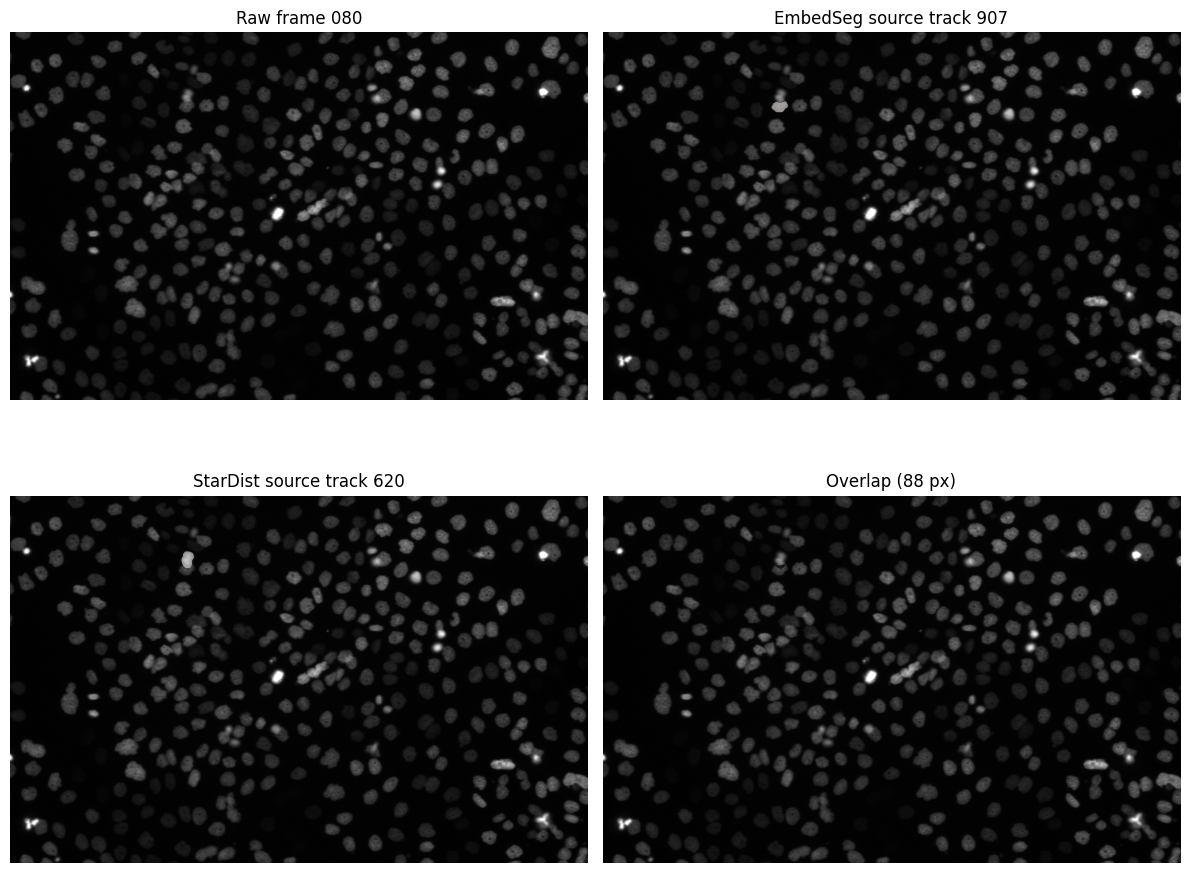

In [9]:
# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax_raw, ax_embedseg, ax_stardist, ax_overlap = axes.ravel()

ax_raw.imshow(raw, cmap="gray")
ax_raw.set_title(f"Raw frame {FRAME_INDEX:03d}")
ax_raw.axis("off")

ax_embedseg.imshow(raw, cmap="gray")
ax_embedseg.imshow(np.ma.masked_where(~embedseg_track, embedseg_track), cmap="Reds", alpha=0.5)
ax_embedseg.set_title(f"EmbedSeg source track {EMBEDSEG_SOURCE_TRACK_ID}")
ax_embedseg.axis("off")

ax_stardist.imshow(raw, cmap="gray")
ax_stardist.imshow(np.ma.masked_where(~stardist_track, stardist_track), cmap="Blues", alpha=0.5)
ax_stardist.set_title(f"StarDist source track {STARDIST_SOURCE_TRACK_ID}")
ax_stardist.axis("off")

ax_overlap.imshow(raw, cmap="gray")
ax_overlap.imshow(np.ma.masked_where(~overlap, overlap), cmap="magma", alpha=0.7)
ax_overlap.set_title(f"Overlap ({overlap_pixels} px)")
ax_overlap.axis("off")

plt.tight_layout()
plt.show()

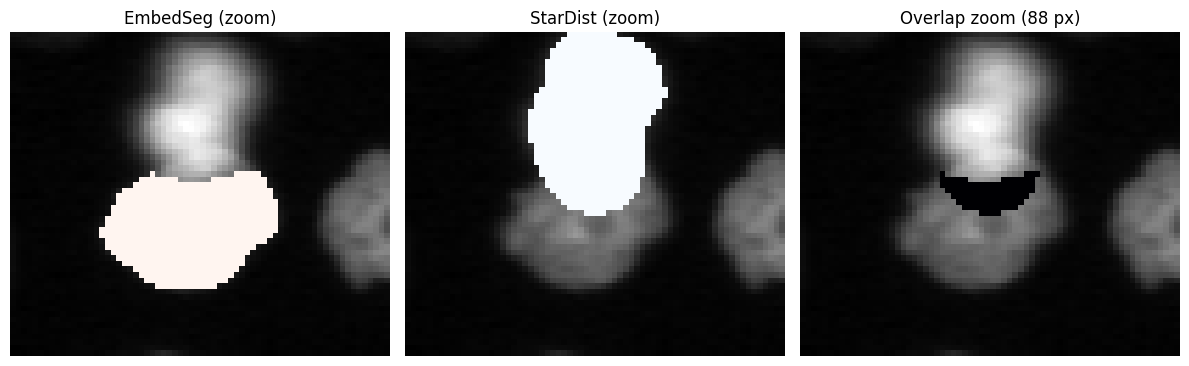

In [12]:
# --- Zoomed overlap view ---
if overlap_pixels > 0:
    ys, xs = np.where(overlap)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    pad = 25
    y0 = max(0, y0 - pad)
    y1 = min(raw.shape[0] - 1, y1 + pad)
    x0 = max(0, x0 - pad)
    x1 = min(raw.shape[1] - 1, x1 + pad)
    zoom = (slice(y0, y1 + 1), slice(x0, x1 + 1))
    raw_z = raw[zoom]
    embed_z = embedseg_track[zoom]
    star_z = stardist_track[zoom]
    overlap_z = overlap[zoom]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    ax0, ax1, ax2 = axes
    ax0.imshow(raw_z, cmap="gray")
    ax0.imshow(np.ma.masked_where(~embed_z, embed_z), cmap="Reds", alpha=1)
    ax0.set_title("EmbedSeg (zoom)")
    ax0.axis("off")

    ax1.imshow(raw_z, cmap="gray")
    ax1.imshow(np.ma.masked_where(~star_z, star_z), cmap="Blues", alpha=1)
    ax1.set_title("StarDist (zoom)")
    ax1.axis("off")

    ax2.imshow(raw_z, cmap="gray")
    ax2.imshow(np.ma.masked_where(~overlap_z, overlap_z), cmap="magma", alpha=1)
    ax2.set_title(f"Overlap zoom ({overlap_pixels} px)")
    ax2.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No overlap pixels found; nothing to zoom.")

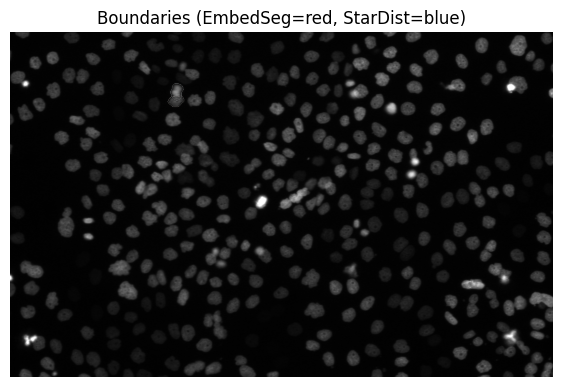

In [11]:
# --- Boundary overlay (optional) ---
embedseg_boundary = find_boundaries(embedseg_track, mode="outer")
stardist_boundary = find_boundaries(stardist_track, mode="outer")

plt.figure(figsize=(7, 7))
plt.imshow(raw, cmap="gray")
plt.imshow(np.ma.masked_where(~embedseg_boundary, embedseg_boundary), cmap="Reds", alpha=0.9)
plt.imshow(np.ma.masked_where(~stardist_boundary, stardist_boundary), cmap="Blues", alpha=0.9)
plt.title("Boundaries (EmbedSeg=red, StarDist=blue)")
plt.axis("off")
plt.show()